### Uses R v4.3.3.

### Uncomment to install BiocManager and DESeq2.  Comment back out after running once.  It's not necessary to reinstall every time the notebook is ran.

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install(version = "3.18")
# BiocManager::install(c("edgeR"))

### Uncomment out each package individually and run the cell to install each package.  Do this one at a time and watch the terminal output to see if any additional dependencies need to be installed on your system.  This is espeically true on Linux where you need to install other packages from the package manager.

In [2]:
# install.packages('readr', version='2.1.5')
# install.packages('dplyr', version='1.1.4')
# install.packages('plotly', version='4.10.4')

In [3]:
library(readr)
library(dplyr)

library(edgeR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: limma



# Differential expression analysis of RNA-seq Data using edgeR: A comparative study of Ryan and Vlasov datasets reflecting healthy versus fatal cases from severe acute COVID-19.

### Introduction:
This analysis focuses on the DEGs analysis of two datasets, Ryan Et al and Vlasov Et al that were uniformly processed using the Bwb software, using the edgeR package set to FDR < 0.05 and a log2foldchange = 1.25.  The input sample sheet intergrates metadata from both datasets and filters the gene expression data acoordingly. The overall aim is to identify key genes that reflect significant expression differences between the two groups of participants (Healthy versus fatal cases secondary to severe active COVID-19). The compendium was built using samples from Australia (group A) and Russia (Group I) as shown in the diagram below pathway (v).

### Specific Objectives
1. **Data Processing** - Importing and cleaning the metadata
2. **Filtering out Low Expression Genes** - Dropping genes with low expression to improve statistical power
3. **Normalization** - Using Trimmed Mean of M-values to adjust for differences in sequencing depth
4. **Differential expression analysis** - Using a negative binomial exact test (see here for the packge documentation)
5. **Extract and interpret top DEGs** - to highlight their biological relevance
6. **Set-up for downstream GSEA** - use the outputs to create rank lists for GSEA (different notebook)

![Study design](./images/Study_design.png)

### Data Processing - Importing and cleaning the metadata

In this section, we import the normalized counts matrix from Bwb's uniform processing as our input for the Ryan Et part of the dataset.  We will later filter it to keep only the relevant samples using our sample sheet created using a different notebook.

The input file is cleaned by removing suffixes from the column headers to allow for congruence with other datasets that we will concatenate with.  We will sort the columns for consistency and then perform a sanity check by display the head to show only a few rows of the output.

## Change the Ryan Gene Counts location by updating the read.csv() value.

In [4]:
# Read Ryan counts
ryan.counts <- as.matrix(read.csv("./data/Ryan/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(ryan.counts) <- sapply(strsplit(colnames(ryan.counts), "_"), `[`, 1)

# Order the dataframe by column name
ryan.counts <- ryan.counts[, sort(colnames(ryan.counts))]

head(ryan.counts)

,SRR14076246,SRR14076247,SRR14076248,SRR14076249,SRR14076250,SRR14076251,SRR14076252,SRR14076253,SRR14076254,SRR14076255,⋯,SRR15510595,SRR15510596,SRR15510597,SRR15510598,SRR15510599,SRR15510600,SRR15510601,SRR15510602,SRR15510603,SRR15510604
ENSG00000268674,0,0,0,0,0,0,1,0,2,1,⋯,2,0,5,0,0,0,0,1,1,0
ENSG00000271254,72,50,203,199,96,130,75,76,228,181,⋯,215,318,169,146,269,241,257,154,279,94
ENSG00000275063,2,5,0,0,0,0,5,8,1,0,⋯,9,0,1,4,5,0,0,0,2,0
ENSG00000277856,0,1,0,0,0,0,2,1,0,0,⋯,0,1,0,1,1,0,0,0,0,0
ENSG00000276345,0,0,6,0,0,8,111,72,151,113,⋯,0,0,0,0,5,2,8,432,5,0
ENSG00000278633,4,0,7,7,2,0,10,0,12,2,⋯,9,8,22,1,11,16,19,2,7,0


We also want to see the dimensions of our normalized count matrix which will be useful as we concatenate with the Vlasov Et al dataset.  In
this case, we have 38,592 genes in the rows and 152 samples in columns all together.

In [5]:
dim(ryan.counts)

[1] 38592   152

We perform similar actions with regard to the Vlasov Et al dataset in the next 2 cells.

## Change the Vlasov Gene Counts location by updating the read.csv() value.

In [6]:
# Read Vlasov counts
vlasov.counts <- as.matrix(read.csv("./data/Vlasov/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(vlasov.counts) <- sapply(strsplit(colnames(vlasov.counts), "_"), `[`, 1)

# Order the dataframe by column name
vlasov.counts <- vlasov.counts[, sort(colnames(vlasov.counts))]

head(vlasov.counts)

,SRR16317814,SRR16317815,SRR16317816,SRR16317817,SRR16317818,SRR16317819,SRR16317820,SRR16317821,SRR16317822,SRR16317823,SRR16317824,SRR16317825,SRR16317826,SRR16317827,SRR16317828,SRR16317829
ENSG00000268674,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000271254,70,84,57,50,31,28,42,31,85,72,68,62,94,105,64,89
ENSG00000275063,148,118,415,474,121,99,11,12,117,129,15,29,164,221,507,530
ENSG00000277856,101,78,173,168,48,54,9,24,76,81,15,26,109,136,325,361
ENSG00000276345,185,151,127,120,85,83,127,34,41,98,0,0,121,100,202,191
ENSG00000278633,5,13,8,3,4,2,10,3,13,10,15,12,4,5,13,2


In [7]:
dim(vlasov.counts)

[1] 38592    16

As we can see here, the number of genes (rows) in Vlasov Et al is also 38,592 just like in the Ryan Et al data set.  We have
fewer total samples (columns) with only 16 as oppossed to Ryan Et al which had 152 samples.  The process of subsetting will lead to a more
balanced dataset compendium for comparison.

### Loading the metadata

Now that we have the normalized data with counts matrix from each group (Ryan and Vlasov), we need the metadata which will guide us in 
subsetting our data with respect to clinical attributes like presence or healthy, fatal cases, and survivors of severe acute COVID-19. We include the sample sheets for our desired comparisons which are those that were healty and the deceased secondary to severe acute COVID-19.

We also prepare the metadata dataset by removing the extra index column, combining all relevant sample sheets for inclusion, then sorting by sample name "Run".

## Change the Compendium metadata locations by updating the read_tsv() values.

In [8]:
# Read Andrew's Compendium data: Group A - Ryan
sample.sheet.healthy.af = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_af.csv")
sample.sheet.healthy.am = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_am.csv")

# Remove first column from dataframes
sample.sheet.healthy.af <- sample.sheet.healthy.af[c(2:length(colnames(sample.sheet.healthy.af)))]
sample.sheet.healthy.am <- sample.sheet.healthy.am[c(2:length(colnames(sample.sheet.healthy.am)))]

# Concatenate dataframes
ryan.sample.sheet.healthy <- rbind(sample.sheet.healthy.af, sample.sheet.healthy.am)

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.healthy <- arrange(ryan.sample.sheet.healthy, Run)

ryan.sample.sheet.healthy

New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


We then subset the output to only include the the sample name "Run" and "disease-severity" columns where we only want
those that are healthy.  There are 14 cases that fit this criteria.

In [9]:
# Reduce and convert ryan_sample_sheet_healthy into sheet that can be concatenated
ryan.sample.sheet.healthy.reduced = ryan.sample.sheet.healthy[c("Run", "disease_severity")]
                                            
ryan.sample.sheet.healthy.reduced                         

Run,disease_severity
<chr>,<chr>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


We perform the same operations on the Vlasov Et al dataset to yield 6 samples where participants had healed from severe acute
COVID-19.

## Change the Compendium metadata locations by updating the read_tsv() values.

In [10]:
# Read Andrew's Compendium data: Group I - Vlasov
vlasov.metadata.i = read.csv("./Andrews_Compendium/output/vlasov_sample_sheet_covid_i.csv")

vlasov.metadata.i

Run,age,Assay.Type,AvgSpotLen,Bases,batch,BioProject,BioSample,Bytes,Center.Name,⋯,rin,rna_extraction_time,create_date,version,sample_extraction_time,Sample.Name,source_name,SRA.Study,survival_status,tissue
<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
SRR16317814,63,RNA-Seq,50,601066000,Batch 1,PRJNA771040,SAMN22249188,275643425,GEO,⋯,NA,2020-12-03T11:00:00Z,2021-10-13T15:53:00Z,1,12/2/2020 18:00,GSM5624883,blood of patient with COVID-19 101 – replication 1,SRP341246,deceased,blood
SRR16317815,63,RNA-Seq,50,562428800,Batch 1,PRJNA771040,SAMN22249189,258643662,GEO,⋯,NA,2020-12-03T11:00:00Z,2021-10-13T15:52:00Z,1,12/2/2020 18:00,GSM5624884,blood of patient with COVID-19 101 – replication 2,SRP341246,deceased,blood
SRR16317820,66,RNA-Seq,50,613339850,Batch 1,PRJNA771040,SAMN22249195,281566156,GEO,⋯,9.4,2020-11-17T14:40:00Z,2021-10-13T15:53:00Z,1,11/16/2020 19:30,GSM5624889,blood of patient with COVID-19 38 – replication 1,SRP341246,deceased,blood
SRR16317821,66,RNA-Seq,50,638412700,Batch 1,PRJNA771040,SAMN22249196,292367728,GEO,⋯,9.4,2020-11-17T14:40:00Z,2021-10-13T15:53:00Z,1,11/16/2020 19:30,GSM5624890,blood of patient with COVID-19 38 – replication 2,SRP341246,deceased,blood
SRR16317826,72,RNA-Seq,50,546528950,Batch 1,PRJNA771040,SAMN22249202,250987146,GEO,⋯,9.8,2020-12-02T00:00:00Z,2021-10-13T15:51:00Z,1,12/2/2020,GSM5624895,blood of patient with COVID-19 98 – replication 1,SRP341246,deceased,blood
SRR16317827,72,RNA-Seq,50,645548350,Batch 1,PRJNA771040,SAMN22249203,296014354,GEO,⋯,9.8,2020-12-02T00:00:00Z,2021-10-13T15:53:00Z,1,12/2/2020,GSM5624896,blood of patient with COVID-19 98 – replication 2,SRP341246,deceased,blood


In [11]:
# Reduce and convert vlasov.metadata.i into sheet that can be concatenated
vlasov.metadata.i.reduced = vlasov.metadata.i[c("Run", "survival_status")]
colnames(vlasov.metadata.i.reduced)[2] <- "disease_severity"
                                            
vlasov.metadata.i.reduced             

Run,disease_severity
<chr>,<chr>
SRR16317814,deceased
SRR16317815,deceased
SRR16317820,deceased
SRR16317821,deceased
SRR16317826,deceased
SRR16317827,deceased


In [12]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.counts.of.interest <- ryan.counts[, ryan.sample.sheet.healthy$Run]

head(ryan.counts.of.interest)

,SRR14076274,SRR14076275,SRR14076280,SRR14076281,SRR14076285,SRR14076286,SRR14076291,SRR14076292,SRR14076319,SRR14076320,SRR14076325,SRR14076326,SRR14076331,SRR14076332
ENSG00000268674,0,0,0,2,0,0,0,0,1,0,0,0,0,1
ENSG00000271254,153,68,59,141,87,127,97,161,129,149,71,271,138,178
ENSG00000275063,0,0,0,0,0,2,5,10,14,1,8,2,8,0
ENSG00000277856,0,0,0,0,0,4,0,0,1,1,1,1,1,0
ENSG00000276345,0,110,80,0,2,2,0,239,0,2,7,0,140,149
ENSG00000278633,0,14,2,6,2,0,0,0,6,0,1,12,0,0


In [13]:
# Create dataframe from Gene Counts that only contains samples from compendium
vlasov.counts.of.interest <- vlasov.counts[, vlasov.metadata.i$Run]

head(vlasov.counts.of.interest)

,SRR16317814,SRR16317815,SRR16317820,SRR16317821,SRR16317826,SRR16317827
ENSG00000268674,0,0,0,0,0,0
ENSG00000271254,70,84,42,31,94,105
ENSG00000275063,148,118,11,12,164,221
ENSG00000277856,101,78,9,24,109,136
ENSG00000276345,185,151,127,34,121,100
ENSG00000278633,5,13,10,3,4,5


Here, we will combine the Ryan and Vlasov subsetted datasets into one using rbind().  We will then make the disease severity
attribute our factor in preparation for analysis. Finally we will do a sanity check for visual reassurance.

In [14]:
# Concatinate Ryan and Vlasov counts of interest
counts.of.interest <- cbind(ryan.counts.of.interest, vlasov.counts.of.interest)

dim(counts.of.interest)

[1] 38592    20

In [15]:
# Remove Genes that only contain 0s
counts.of.interest.filtered <- counts.of.interest[apply(counts.of.interest != 0, 1, sum) != 0,]
dim(counts.of.interest.filtered)

[1] 33939    20

In [16]:
# Concatinate Ryan and Vlasov metadata
metadata <- rbind(ryan.sample.sheet.healthy.reduced, vlasov.metadata.i.reduced)

metadata$disease_severity <- factor(metadata$disease_severity)

metadata

Run,disease_severity
<chr>,<fct>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


Next, we will create a DGEList object which will be the foundation of our analysis.  This method (See help() of the package) will help us filter genes based on expression levels, normalize the gene counts, create a design matrix for comparison, then it will estimate dispersion
(which is the variance in gene expression).  After this, it will perform statistical testing.

In [17]:
# Defining two groups and assigning to the variable "group"
group <- factor(c(rep(1,14), rep(2, 6)))

In [18]:
# Preparing the data for normalization, filtering, and DEA
y <- DGEList(counts=counts.of.interest.filtered, group=group)

In [19]:
# Filtering out genes to keep only those with more than 3 copies per million in at least 5 samples.
dim(y)
keep <- rowSums(cpm(y)>3) > 5
table(keep)

[1] 33939    20

keep
FALSE  TRUE 
20924 13015 

In [20]:
# Removing those genes that were filter out to only keep the 13,015 genes
y <- y[keep, , keep.lib.sizes=FALSE]
tokeep = rownames(y)
dim(y)

[1] 13015    20

In [21]:
# Normalization with edgeR
y <- calcNormFactors(y)

In [22]:
# Creating the Design matrix
design <- model.matrix(~group)

In [23]:
# Estimating dispersions
y <- estimateDisp(y)

Using classic mode.



In [24]:
# Inferring differential expression
et <- exactTest(y)

In [25]:
# Subsetting top DEGs
top20.genes <- rownames(topTags(et, n=20)$table)
top50.genes <- rownames(topTags(et, n=50)$table)
top100.genes <- rownames(topTags(et, n=100)$table)

In [26]:
# Obtaining expression levels of top 20 genes from counts of interest
raw.cnts.top20 <- counts.of.interest[top20.genes, ]

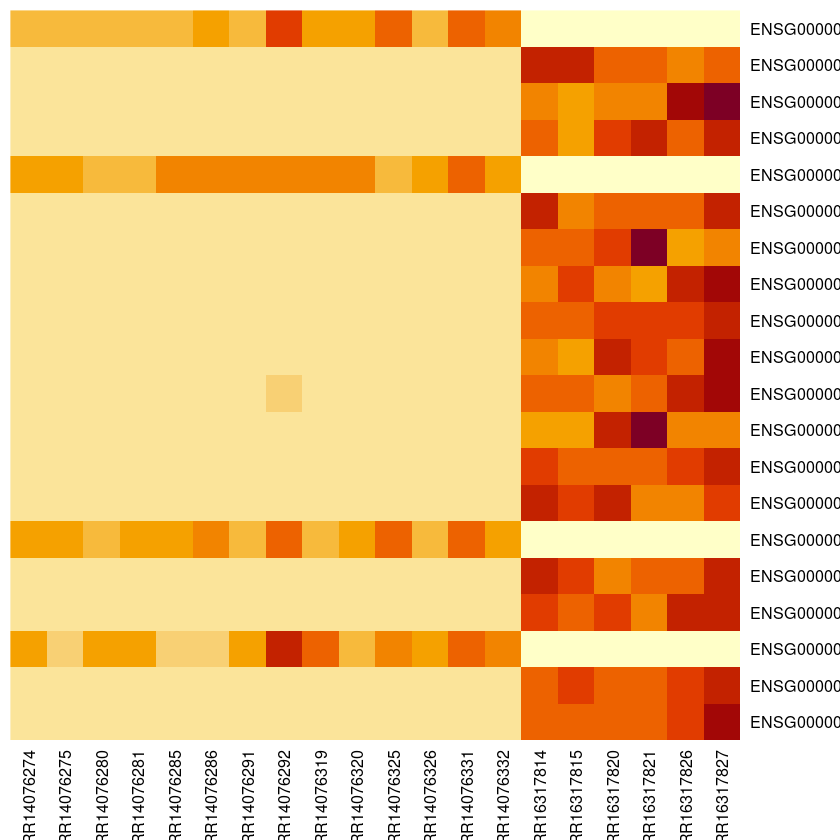

In [27]:
# Heatmap visualization of top 20 genes
heatmap(as.matrix(raw.cnts.top20), Colv=NA, Rowv=NA)

In [28]:
# Obtaining expression levels of top 50 genes from counts of interest
raw.cnts.top50 <- counts.of.interest[top50.genes, ]

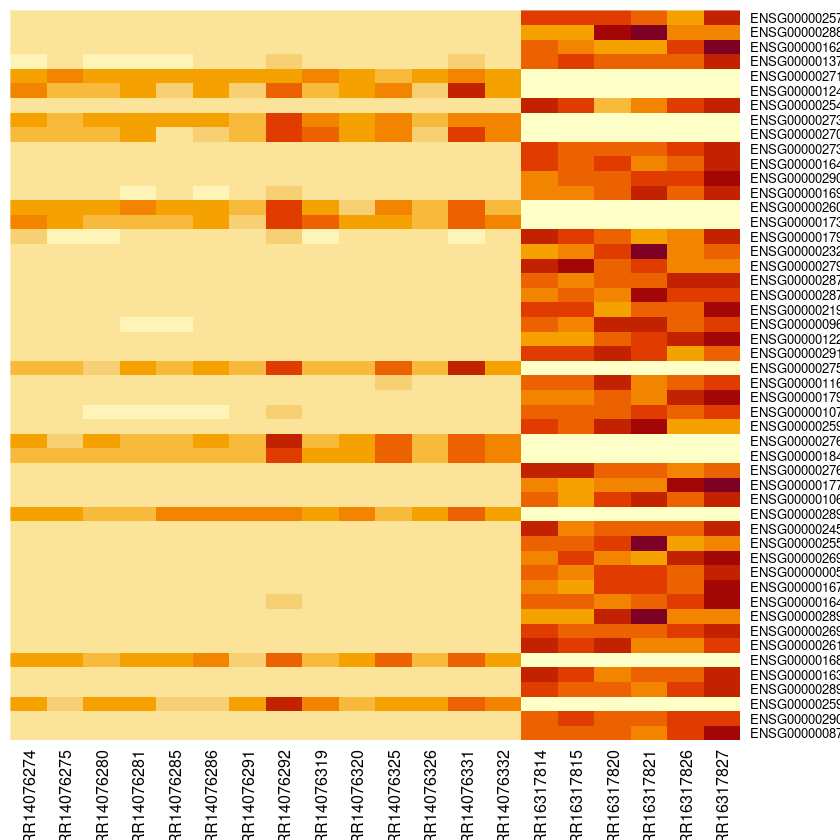

In [29]:
# Heatmap visualization of top 50 genes
heatmap(as.matrix(raw.cnts.top50), Colv=NA, Rowv=NA)

In [30]:
# Obtaining expression levels of top 100 genes from counts of interest
raw.cnts.top100 <- counts.of.interest[top100.genes, ]

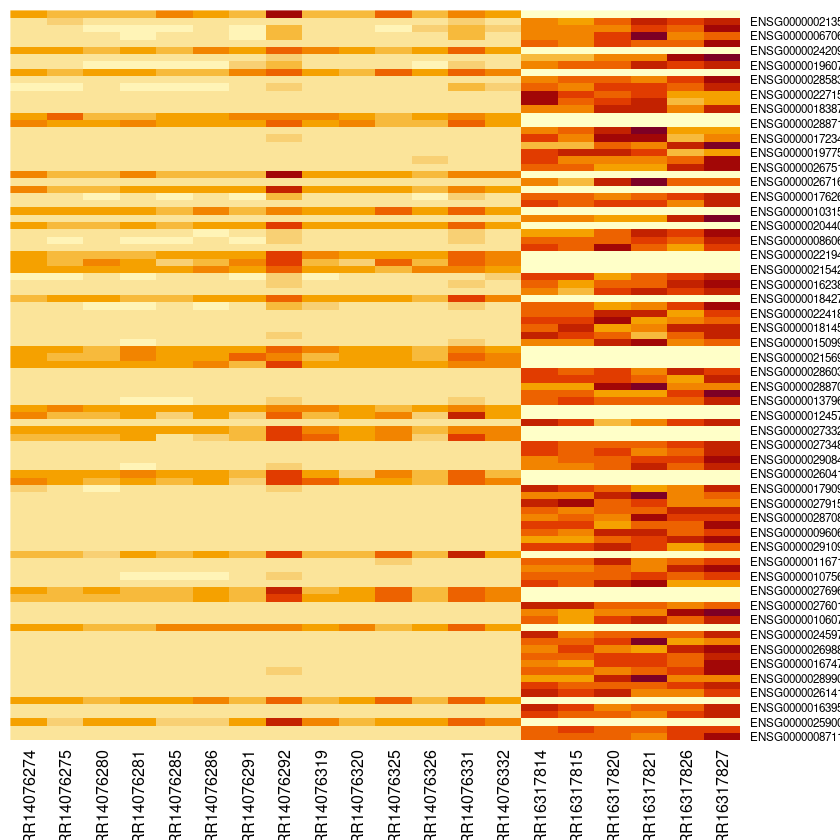

In [31]:
# Heatmap visualization of top 100 genes
heatmap(as.matrix(raw.cnts.top100), Colv=NA, Rowv=NA)

In [32]:
# Extracting the top differentially expressed genes
deg_results_AvsI <- topTags(et, n = Inf)$table
head(deg_results_AvsI)

,logFC,logCPM,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000087116,9.503224,6.222841,0.000000e+00,0.000000e+00
ENSG00000290574,9.493629,3.237684,0.000000e+00,0.000000e+00
ENSG00000259001,-9.660369,10.949421,3.275998e-286,1.421237e-282
ENSG00000289100,3.759638,4.797245,1.439991e-269,4.685370e-266
ENSG00000163959,7.102948,1.895331,9.860118e-217,2.566589e-213
ENSG00000168298,-7.130151,6.989595,1.121830e-210,2.433436e-207


### Notice

The next slide can be saved as a .csv excel spread sheet by uncommenting the code snippet while leaving the comment with the '#'.

In [33]:
# Ensure row names (gene IDs) are saved as a column
#deg_results_AvsI$GeneID <- rownames(deg_results_AvsI)

# Save the file with GeneID included
#write.csv(deg_results_AvsI, file = file.path(getwd(), "deg_results_AvsI.csv"), row.names = FALSE)
